# MODEL BUILDING

Including:

- Feature Engineering
- Feature Selection
- Model Iterations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import CategoricalDtype

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as IMB_Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, brier_score_loss,
    ConfusionMatrixDisplay, classification_report
)

import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
df = pd.read_csv('../datasets/cleaned_data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   year                        869319 non-null  int64  
 1   age_group                   869319 non-null  str    
 2   age                         869319 non-null  float64
 3   sex                         869319 non-null  str    
 4   race                        869319 non-null  str    
 5   weight                      869319 non-null  float64
 6   height                      869319 non-null  float64
 7   bmi                         869319 non-null  float64
 8   marital_status              869319 non-null  str    
 9   education_level             869319 non-null  str    
 10  education                   869319 non-null  float64
 11  employment_status           869319 non-null  str    
 12  income_level                869319 non-null  str    
 13  income                   

In [55]:
df.columns

Index(['year', 'age_group', 'age', 'sex', 'race', 'weight', 'height', 'bmi',
       'marital_status', 'education_level', 'education', 'employment_status',
       'income_level', 'income', 'general_health', 'gen_health',
       'physical_health_days', 'mental_health_days', 'exercise',
       'smoked_100_cigarettes', 'drinks_alcohol', 'high_bp', 'had_stroke',
       'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier',
       'last_checkup', 'l_checkup', 'has_personal_doctor', 'diabetes'],
      dtype='str')

In [56]:
df.head()

,year,age_group,age,sex,race,weight,height,bmi,marital_status,education_level,education,employment_status,income_level,income,general_health,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,last_checkup,l_checkup,has_personal_doctor,diabetes
0,2019,40 - 44,5.0,Female,White,220.0,66.0,35.51,Never married,Some college (1-3 years) or Technical school,5.0,A homemaker,"<$10,000",1.0,Very Good,2.0,0.0,30.0,False,True,False,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
1,2019,60 - 64,9.0,Male,White,150.0,66.0,24.21,Divorced,Some college (1-3 years) or Technical school,5.0,Unable to work,"<$10,000",1.0,Fair,4.0,3.0,12.0,True,True,False,Yes,False,False,False,False,<1 year,1.0,No,Non-diabetic
2,2019,45 - 49,6.0,Female,White,148.0,61.0,27.96,Divorced,High school graduate (12 or GED),4.0,Employed for wages,"<$10,000",1.0,Good,3.0,0.0,10.0,True,True,True,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Diabetic
3,2019,45 - 49,6.0,Male,White,220.0,71.0,30.68,Married,High school graduate (12 or GED),4.0,Employed for wages,"$75,000 - <$100,000",8.0,Very Good,2.0,0.0,0.0,True,True,False,No,False,False,False,False,<1 year,1.0,No,Non-diabetic
4,2019,65 - 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,High school graduate (12 or GED),4.0,Retired,"$15,000 - <$20,000",3.0,Fair,4.0,30.0,0.0,False,True,False,Yes,True,False,False,False,<1 year,1.0,"Yes, only one",Diabetic


### Feature Selection

To drop:
- year
- age group
- race (won't be relevant for this model)
- weight and height (multicolinearity with bmi, which is a derivative of both)
- education_level
- income level
- general health
- last_checkup

Recode general health, so that: Excellent is 5, and Poor is 1

In [57]:
df.general_health.value_counts()

general_health
Very Good    303836
Good         274836
Excellent    144028
Fair         110367
Poor          36252
Name: count, dtype: int64

In [58]:
df.gen_health.value_counts()

gen_health
2.0    303836
3.0    274836
1.0    144028
4.0    110367
5.0     36252
Name: count, dtype: int64

### Process Income Level

Put in three categories

In [59]:
df.head()

,year,age_group,age,sex,race,weight,height,bmi,marital_status,education_level,education,employment_status,income_level,income,general_health,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,last_checkup,l_checkup,has_personal_doctor,diabetes
0,2019,40 - 44,5.0,Female,White,220.0,66.0,35.51,Never married,Some college (1-3 years) or Technical school,5.0,A homemaker,"<$10,000",1.0,Very Good,2.0,0.0,30.0,False,True,False,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
1,2019,60 - 64,9.0,Male,White,150.0,66.0,24.21,Divorced,Some college (1-3 years) or Technical school,5.0,Unable to work,"<$10,000",1.0,Fair,4.0,3.0,12.0,True,True,False,Yes,False,False,False,False,<1 year,1.0,No,Non-diabetic
2,2019,45 - 49,6.0,Female,White,148.0,61.0,27.96,Divorced,High school graduate (12 or GED),4.0,Employed for wages,"<$10,000",1.0,Good,3.0,0.0,10.0,True,True,True,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Diabetic
3,2019,45 - 49,6.0,Male,White,220.0,71.0,30.68,Married,High school graduate (12 or GED),4.0,Employed for wages,"$75,000 - <$100,000",8.0,Very Good,2.0,0.0,0.0,True,True,False,No,False,False,False,False,<1 year,1.0,No,Non-diabetic
4,2019,65 - 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,High school graduate (12 or GED),4.0,Retired,"$15,000 - <$20,000",3.0,Fair,4.0,30.0,0.0,False,True,False,Yes,True,False,False,False,<1 year,1.0,"Yes, only one",Diabetic


In [60]:
df.income_level.unique()

<ArrowStringArray>
[            '<$10,000',  '$75,000 - <$100,000',   '$15,000 - <$20,000',
   '$35,000 - <$50,000',   '$20,000 - <$25,000',   '$50,000 - <$75,000',
   '$25,000 - <$35,000',   '$10,000 - <$15,000',            '$200,000+',
 '$100,000 - <$150,000', '$150,000 - <$200,000']
Length: 11, dtype: str

In [61]:
# 1. Define the explicit numeric mapping (1 = Low, 2 = Medium, 3 = High)
income_tier_map = {
    # Low Income Tier (1)
    '<$10,000': 1,
    '$10,000 - <$15,000': 1,
    '$15,000 - <$20,000': 1,
    '$20,000 - <$25,000': 1,
    
    # Medium Income Tier (2)
    '$25,000 - <$35,000': 2,
    '$35,000 - <$50,000': 2,
    '$50,000 - <$75,000': 2,
    
    # High Income Tier (3)
    '$75,000 - <$100,000': 3,
    '$100,000 - <$150,000': 3,
    '$150,000 - <$20,000': 3,  # Captures the exact string variation in list
    '$150,000 - <$200,000': 3,
    '$200,000+': 3
}

# 2. Apply the mapping to create the new numerical feature
df['socioeconomic_tier'] = df['income_level'].map(income_tier_map)

# 3. Verification Check
print("Value counts for the new numeric feature:")
print(df['socioeconomic_tier'].value_counts(dropna=False))

Value counts for the new numeric feature:
socioeconomic_tier
2    361678
3    355990
1    151651
Name: count, dtype: int64


In [62]:
df.gen_health = 6 - df.gen_health
df.head()

to_drop = ['year', 'age_group', 'race', 'weight', 'height', 'education_level', 'income_level',
           'income', 'general_health', 'last_checkup']

df.drop(columns=to_drop, inplace=True)
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         869319 non-null  float64
 1   sex                         869319 non-null  str    
 2   bmi                         869319 non-null  float64
 3   marital_status              869319 non-null  str    
 4   education                   869319 non-null  float64
 5   employment_status           869319 non-null  str    
 6   gen_health                  869319 non-null  float64
 7   physical_health_days        869319 non-null  float64
 8   mental_health_days          869319 non-null  float64
 9   exercise                    869319 non-null  bool   
 10  smoked_100_cigarettes       869319 non-null  bool   
 11  drinks_alcohol              869319 non-null  bool   
 12  high_bp                     869319 non-null  str    
 13  had_stroke               

,age,sex,bmi,marital_status,education,employment_status,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,l_checkup,has_personal_doctor,diabetes,socioeconomic_tier
0,5.0,Female,35.51,Never married,5.0,A homemaker,4.0,0.0,30.0,False,True,False,Yes,False,False,False,False,1.0,"Yes, only one",Non-diabetic,1
1,9.0,Male,24.21,Divorced,5.0,Unable to work,2.0,3.0,12.0,True,True,False,Yes,False,False,False,False,1.0,No,Non-diabetic,1
2,6.0,Female,27.96,Divorced,4.0,Employed for wages,3.0,0.0,10.0,True,True,True,Yes,False,False,False,False,1.0,"Yes, only one",Diabetic,1
3,6.0,Male,30.68,Married,4.0,Employed for wages,4.0,0.0,0.0,True,True,False,No,False,False,False,False,1.0,No,Non-diabetic,3
4,10.0,Male,37.33,Widowed,4.0,Retired,2.0,30.0,0.0,False,True,False,Yes,True,False,False,False,1.0,"Yes, only one",Diabetic,1


In [63]:
df.high_bp.value_counts()

high_bp
No            506765
Yes           353556
Borderline      8998
Name: count, dtype: int64

In [3]:
# compiled preprocessing
def wrangle(filepath="../datasets/cleaned_data.csv"):
    # read cleaned data
    df = pd.read_csv(filepath)

    # 1. Define the explicit numeric mapping (1 = Low, 2 = Medium, 3 = High)
    income_tier_map = {
        # Low Income Tier (1)
        '<$10,000': 1,
        '$10,000 - <$15,000': 1,
        '$15,000 - <$20,000': 1,
        '$20,000 - <$25,000': 1,
        
        # Medium Income Tier (2)
        '$25,000 - <$35,000': 2,
        '$35,000 - <$50,000': 2,
        '$50,000 - <$75,000': 2,
        
        # High Income Tier (3)
        '$75,000 - <$100,000': 3,
        '$100,000 - <$150,000': 3,
        '$150,000 - <$20,000': 3,  # Captures the exact string variation in list
        '$150,000 - <$200,000': 3,
        '$200,000+': 3
    }

    # 2. Apply the mapping to create the new numerical feature
    df['socioeconomic_tier'] = df['income_level'].map(income_tier_map)

    # 3. Verification Check
    print("Value counts for the new numeric feature:")
    print(df['socioeconomic_tier'].value_counts(dropna=False))


    # invert direction of general health so that higher values mean better health
    df.gen_health = 6 - df.gen_health


    # drop redundant and low cardinality features
    to_drop = ['year', 'age_group', 'race', 'weight', 'height', 'education_level', 'income_level',
            'general_health', 'last_checkup']
    df.drop(columns=to_drop, inplace=True)


    # convert True/False columns (boolean) to integers
    t_f_cols = ['smoked_100_cigarettes', 'drinks_alcohol', 'had_stroke', 'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier']
    for col in t_f_cols:
        df[col] = df[col].astype('int8')

    return df


df = wrangle()

Value counts for the new numeric feature:
socioeconomic_tier
2    361678
3    355990
1    151651
Name: count, dtype: int64


In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         869319 non-null  float64
 1   sex                         869319 non-null  str    
 2   bmi                         869319 non-null  float64
 3   marital_status              869319 non-null  str    
 4   education                   869319 non-null  float64
 5   employment_status           869319 non-null  str    
 6   income                      869319 non-null  float64
 7   gen_health                  869319 non-null  float64
 8   physical_health_days        869319 non-null  float64
 9   mental_health_days          869319 non-null  float64
 10  exercise                    869319 non-null  bool   
 11  smoked_100_cigarettes       869319 non-null  int8   
 12  drinks_alcohol              869319 non-null  int8   
 13  high_bp                  

In [66]:
df.head()

,age,sex,bmi,marital_status,education,employment_status,income,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,l_checkup,has_personal_doctor,diabetes,socioeconomic_tier
0,5.0,Female,35.51,Never married,5.0,A homemaker,1.0,4.0,0.0,30.0,False,1,0,Yes,0,0,0,0,1.0,"Yes, only one",Non-diabetic,1
1,9.0,Male,24.21,Divorced,5.0,Unable to work,1.0,2.0,3.0,12.0,True,1,0,Yes,0,0,0,0,1.0,No,Non-diabetic,1
2,6.0,Female,27.96,Divorced,4.0,Employed for wages,1.0,3.0,0.0,10.0,True,1,1,Yes,0,0,0,0,1.0,"Yes, only one",Diabetic,1
3,6.0,Male,30.68,Married,4.0,Employed for wages,8.0,4.0,0.0,0.0,True,1,0,No,0,0,0,0,1.0,No,Non-diabetic,3
4,10.0,Male,37.33,Widowed,4.0,Retired,3.0,2.0,30.0,0.0,False,1,0,Yes,1,0,0,0,1.0,"Yes, only one",Diabetic,1


In [67]:
df[['had_heart_attack', 'had_coronary_heart_disease']].corr()

,had_heart_attack,had_coronary_heart_disease
had_heart_attack,1.000000,0.448444
had_coronary_heart_disease,0.448444,1.000000


<Axes: xlabel='high_bp', ylabel='Count'>

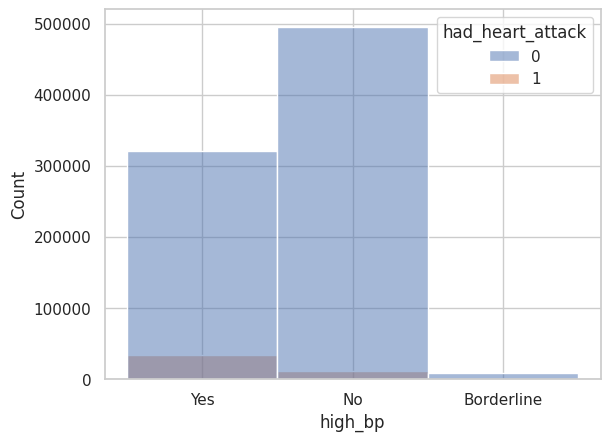

In [68]:
sns.histplot(data=df, x='high_bp', hue='had_heart_attack')

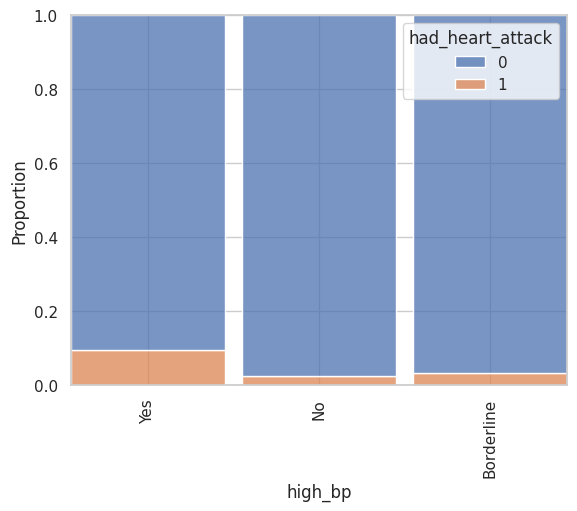

In [69]:
sns.histplot(data=df, x='high_bp', hue='had_heart_attack', multiple='fill', stat='proportion', shrink=0.9)
plt.xticks(rotation=90);

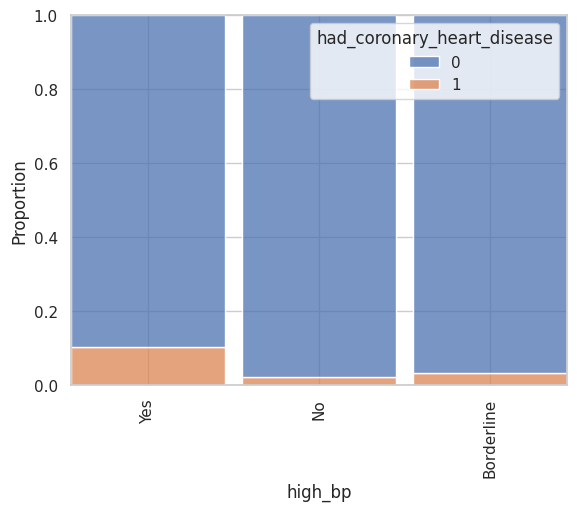

In [70]:
sns.histplot(data=df, x='high_bp', hue='had_coronary_heart_disease', multiple='fill', stat='proportion', shrink=0.9)
plt.xticks(rotation=90);

### Random Guess

In [4]:
df.diabetes.value_counts(normalize=True)

diabetes
Non-diabetic    0.844349
Diabetic        0.133089
Pre-diabetic    0.022561
Name: proportion, dtype: float64

### Split Data

In [6]:
df_1 = df.copy()

In [7]:
target = 'diabetes'

y = df_1[target]
X = df_1.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)

print(f"Training...\nFeatures:  {len(X_train)}\tTarget:  {len(y_train)}")
print(f"Testing...\nFeatures:  {len(X_test)}\tTarget:  {len(y_test)}")

Training...
Features:  825853	Target:  825853
Testing...
Features:  43466	Target:  43466


In [74]:
y_train.value_counts(normalize=True)

diabetes
Non-diabetic    0.844350
Diabetic        0.133089
Pre-diabetic    0.022561
Name: proportion, dtype: float64

In [75]:
y_test.value_counts(normalize=True)

diabetes
Non-diabetic    0.844338
Diabetic        0.133093
Pre-diabetic    0.022569
Name: proportion, dtype: float64

### Baseline Model with Logistic Regression

In [8]:
# build column transformer
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(exclude='number').columns.tolist()


def preprocessor():
    return(
        ColumnTransformer([
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
]))

# build pipeline
logreg = Pipeline([
    ('preprocessor', preprocessor()),
    ('lr', LogisticRegression(random_state=42))
])


logreg.fit(X_train, y_train)

lr_pred = logreg.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, lr_pred)}")
acc = accuracy_score(y_test, lr_pred)



Accuracy: 0.8476970505682603


In [26]:
confusion_matrix(y_test, lr_pred)

array([[  934,  4851,     0],
       [  789, 35911,     0],
       [   74,   907,     0]])

In [27]:
print(logreg.classes_)

['Diabetic' 'Non-diabetic' 'Pre-diabetic']


In [28]:
print(classification_report(
    y_test, lr_pred,
    target_names=logreg.classes_
))

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    Diabetic       0.52      0.16      0.25      5785
Non-diabetic       0.86      0.98      0.92     36700
Pre-diabetic       0.00      0.00      0.00       981

    accuracy                           0.85     43466
   macro avg       0.46      0.38      0.39     43466
weighted avg       0.80      0.85      0.81     43466



/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [29]:
ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred));

### Feature Engineering

#### Collapse diabetes into two classes

In [30]:
df_1.diabetes.unique()

<ArrowStringArray>
['Non-diabetic', 'Diabetic', 'Pre-diabetic']
Length: 3, dtype: str

In [31]:
df.diabetes.value_counts()

diabetes
Non-diabetic    734009
Diabetic        115697
Pre-diabetic     19613
Name: count, dtype: int64

In [77]:
df_1['diabetes'] = df_1['diabetes'].map({'Non-diabetic': 0, 'Pre-diabetic': 1, 'Diabetic': 1})
df_1.diabetes.value_counts()

diabetes
0    734009
1    135310
Name: count, dtype: int64

#### Redo baseline model

In [78]:
target = 'diabetes'

y = df_1[target]
X = df_1.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)

print(f"Training...\nFeatures:  {len(X_train)}\tTarget:  {len(y_train)}")
print(f"Testing...\nFeatures:  {len(X_test)}\tTarget:  {len(y_test)}")

Training...
Features:  825853	Target:  825853
Testing...
Features:  43466	Target:  43466


In [79]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

diabetes
0    0.84435
1    0.15565
Name: proportion, dtype: float64
diabetes
0    0.844338
1    0.155662
Name: proportion, dtype: float64


In [80]:
# build pipeline
logreg2 = Pipeline([
    ('preprocessor', preprocessor()),
    ('lr', LogisticRegression(random_state=42, class_weight='balanced'))
])


logreg2.fit(X_train, y_train)

lr_pred2 = logreg2.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, lr_pred2)}")
acc = accuracy_score(y_test, lr_pred2)
tn, fp, fn, tp = confusion_matrix(y_test, lr_pred2).ravel()
lr_prob = logreg2.predict_proba(X_test)[:, 1]

Accuracy: 0.7287765149772236


In [9]:
# helper functions

def preprocessor():
    return(
        ColumnTransformer([
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
]))

def evaluate_model(name, y_true, y_pred, y_prob):
    """
    Evaluate a binary classifier.
    
    Parameters
    ----------
    name   : str   — model name, used in plot title and dict key
    y_true : array — true labels
    y_pred : array — predicted labels
    y_prob : array — predicted probabilities for positive class
    
    Returns
    -------
    dict of metrics
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        'model'       : name,
        'accuracy'    : accuracy_score(y_true, y_pred),
        'sensitivity' : tp / (tp + fn),
        'specificity' : tn / (tn + fp),
        'ppv'         : tp / (tp + fp),
        'npv'         : tn / (tn + fn),
        'f1'          : tp / (tp + 0.5 * (fp + fn)),   # equivalent, no division chain
        'roc_auc'     : roc_auc_score(y_true, y_prob),
        'avg_precision': average_precision_score(y_true, y_prob),
        'brier'       : brier_score_loss(y_true, y_prob),
    }

    # ── Print ─────────────────────────────────────────────────────────────────
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    for k, v in metrics.items():
        if k == 'model': continue
        print(f"  {k:<18} {v:.4f}")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(name, fontsize=12, fontweight='bold')

    # Confusion matrix
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['Non-diabetic', 'Diabetic']
    ).plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title('Confusion matrix')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, color='steelblue',
                 label=f"AUC = {metrics['roc_auc']:.3f}")
    axes[1].plot([0,1],[0,1], 'k--', linewidth=0.8)
    axes[1].set_xlabel('1 - Specificity')
    axes[1].set_ylabel('Sensitivity')
    axes[1].set_title('ROC curve')
    axes[1].legend()

    # Precision-Recall curve
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    axes[2].plot(rec, prec, color='coral',
                 label=f"AP = {metrics['avg_precision']:.3f}")
    axes[2].axhline(y_true.mean(), linestyle='--', color='gray',
                    linewidth=0.8, label=f"Baseline = {y_true.mean():.3f}")
    axes[2].set_xlabel('Recall (Sensitivity)')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall curve')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f"{name.lower().replace(' ', '_')}_eval.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    return metrics

In [37]:
logreg2.classes_

array([0, 1])


────────────────────────────────────────
  logreg2
────────────────────────────────────────
  accuracy           0.7288
  sensitivity        0.7792
  specificity        0.7195
  ppv                0.3387
  npv                0.9464
  f1                 0.4721
  roc_auc            0.8205
  avg_precision      0.4334
  brier              0.1784


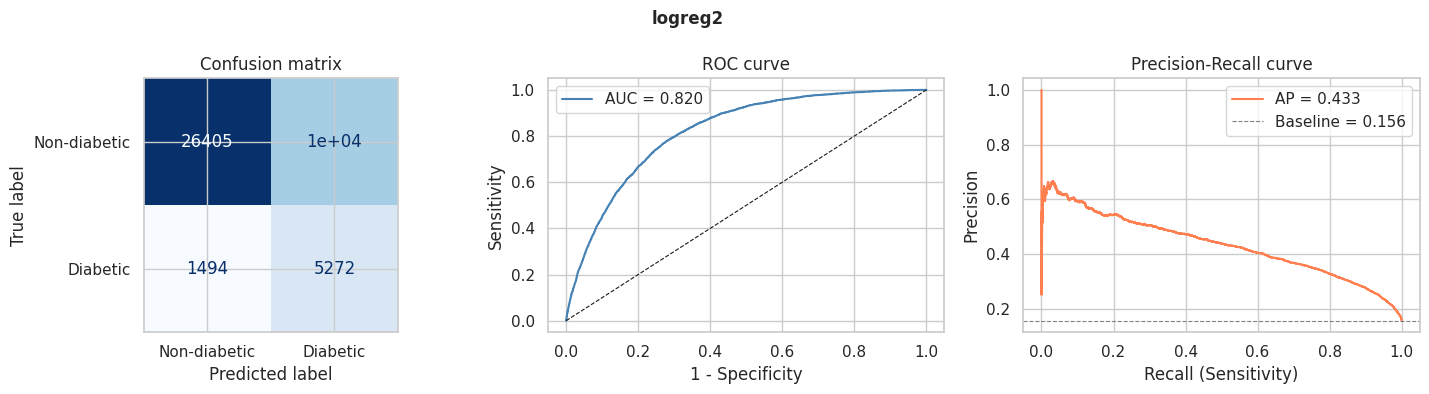

In [82]:
metrics = evaluate_model('logreg2', y_test, lr_pred2,lr_prob)

In [39]:
print(logreg2.classes_)
print(logreg2.predict_proba(X_test[:5]))
print(y_test[:5].values)

[0 1]
[[0.62613644 0.37386356]
 [0.32749613 0.67250387]
 [0.2193246  0.7806754 ]
 [0.97613351 0.02386649]
 [0.18880151 0.81119849]]
[0 0 0 0 0]


In [40]:
logreg2.named_steps

{'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                  ['age', 'bmi', 'education', 'income',
                                   'gen_health', 'physical_health_days',
                                   'mental_health_days', 'smoked_100_cigarettes',
                                   'drinks_alcohol', 'had_stroke',
                                   'had_heart_attack',
                                   'had_coronary_heart_disease', 'cost_barrier',
                                   'l_checkup']),
                                 ('cat', OneHotEncoder(handle_unknown='ignore'),
                                  ['sex', 'marital_status', 'employment_status',
                                   'exercise', 'high_bp',
                                   'has_personal_doctor'])]),
 'lr': LogisticRegression(class_weight='balanced', random_state=42)}

In [41]:
df_1.head()

,age,sex,bmi,marital_status,education,employment_status,income,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,l_checkup,has_personal_doctor,diabetes
0,5.0,Female,35.51,Never married,5.0,A homemaker,1.0,4.0,0.0,30.0,False,1,0,Yes,0,0,0,0,1.0,"Yes, only one",0
1,9.0,Male,24.21,Divorced,5.0,Unable to work,1.0,2.0,3.0,12.0,True,1,0,Yes,0,0,0,0,1.0,No,0
2,6.0,Female,27.96,Divorced,4.0,Employed for wages,1.0,3.0,0.0,10.0,True,1,1,Yes,0,0,0,0,1.0,"Yes, only one",1
3,6.0,Male,30.68,Married,4.0,Employed for wages,8.0,4.0,0.0,0.0,True,1,0,No,0,0,0,0,1.0,No,0
4,10.0,Male,37.33,Widowed,4.0,Retired,3.0,2.0,30.0,0.0,False,1,0,Yes,1,0,0,0,1.0,"Yes, only one",1


**Collapse Marital Status**

In [83]:
df.marital_status.value_counts()

marital_status
Married                            466060
Never married                      146122
Divorced                           116848
Widowed                             86880
A member of an unmarried couple     36757
Separated                           16652
Name: count, dtype: int64

In [84]:
df_1['marital_status'] = df_1['marital_status'].map({
    'Married': 'Married/Cohabiting',
    'A member of an unmarried couple': 'Married/Cohabiting',
    'Never married': 'Single',
    'Divorced': 'Previously Married',
    'Separated': 'Previously Married',
    'Widowed': 'Previously Married'
})

print(df_1.marital_status.value_counts())

marital_status
Married/Cohabiting    502817
Previously Married    220380
Single                146122
Name: count, dtype: int64


**Collapse employment status**

In [85]:
df.employment_status.value_counts()

employment_status
Employed for wages                  394329
Retired                             258061
Self-employed                        80455
Unable to work                       49618
A homemaker                          33487
A student                            19290
Out of work for less that 1 year     17513
Out of work for more than 1 year     16566
Name: count, dtype: int64

In [86]:
df_1['employment_status'] = df_1['employment_status'].map({
    'Employed for wages': 'Employed',
    'Self-employed': 'Employed',
    'Retired': 'Retired',
    'Out of work for less that 1 year': 'Unemployed',
    'Out of work for more than 1 year': 'Unemployed',
    'A homemaker': 'Student/Homemaker',
    'A student': 'Student/Homemaker',
    'Unable to work': 'Unable to work'
})

df_1.employment_status.value_counts()

employment_status
Employed             474784
Retired              258061
Student/Homemaker     52777
Unable to work        49618
Unemployed            34079
Name: count, dtype: int64

In [87]:
df_1.has_personal_doctor.value_counts()

has_personal_doctor
Yes, only one    555994
More than one    200950
No               112375
Name: count, dtype: int64

In [88]:
df_1['has_personal_doctor'] = df_1['has_personal_doctor'].map({
    'Yes, only one': 1, # Yes
    'More than one': 1, # Yes
    "No": 0 # No
})

print(df_1.has_personal_doctor.value_counts())

has_personal_doctor
1    756944
0    112375
Name: count, dtype: int64


#### Rebuild Model

In [89]:
target = 'diabetes'

y = df_1[target]
X = df_1.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)

print(f"Training...\nFeatures:  {len(X_train)}\tTarget:  {len(y_train)}")
print(f"Testing...\nFeatures:  {len(X_test)}\tTarget:  {len(y_test)}")

Training...
Features:  825853	Target:  825853
Testing...
Features:  43466	Target:  43466


Accuracy: 0.7280173008788479

────────────────────────────────────────
  logreg3
────────────────────────────────────────
  accuracy           0.7280
  sensitivity        0.7787
  specificity        0.7187
  ppv                0.3379
  npv                0.9463
  f1                 0.4713
  roc_auc            0.8202
  avg_precision      0.4323
  brier              0.1786


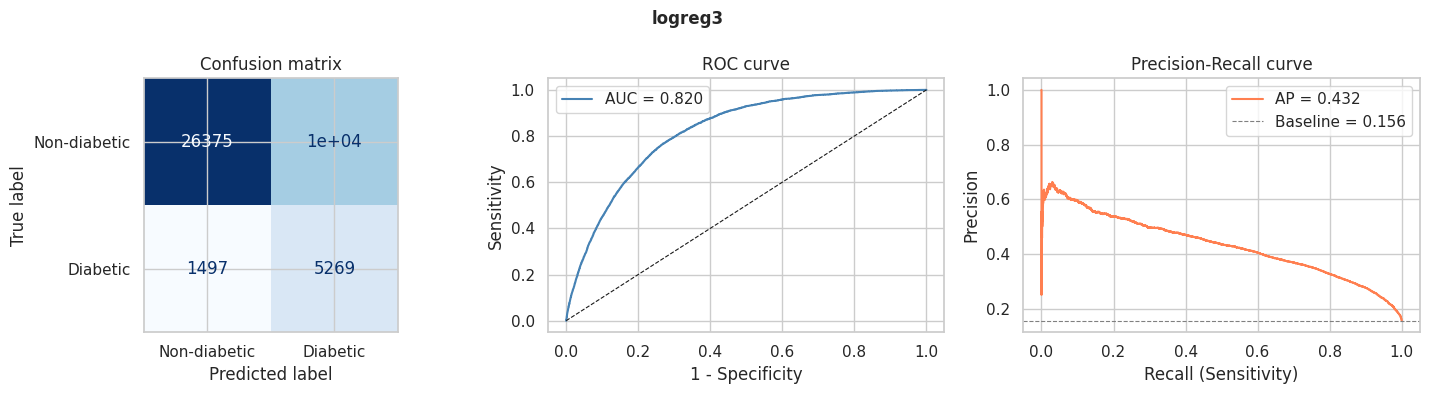

In [ ]:
# build pipeline
logreg3 = Pipeline([
    ('preprocessor', preprocessor()),
    ('lr', LogisticRegression(random_state=42, class_weight='balanced'))
])


logreg3.fit(X_train, y_train)

lr_pred3 = logreg3.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, lr_pred3)}")
# acc = accuracy_score(y_test, lr_pred3)
tn, fp, fn, tp = confusion_matrix(y_test, lr_pred3).ravel()
lr_prob3 = logreg3.predict_proba(X_test)[:, 1]

metrics = evaluate_model('logreg3', y_test, lr_pred3, lr_prob3)

In [50]:
logreg3.named_steps['preprocessor']

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### Try with Oversampled Data

Accuracy: 0.7282013527814843

────────────────────────────────────────
  logreg4
────────────────────────────────────────
  accuracy           0.7282
  sensitivity        0.7749
  specificity        0.7196
  ppv                0.3375
  npv                0.9455
  f1                 0.4702
  roc_auc            0.8195
  avg_precision      0.4303
  brier              0.1775


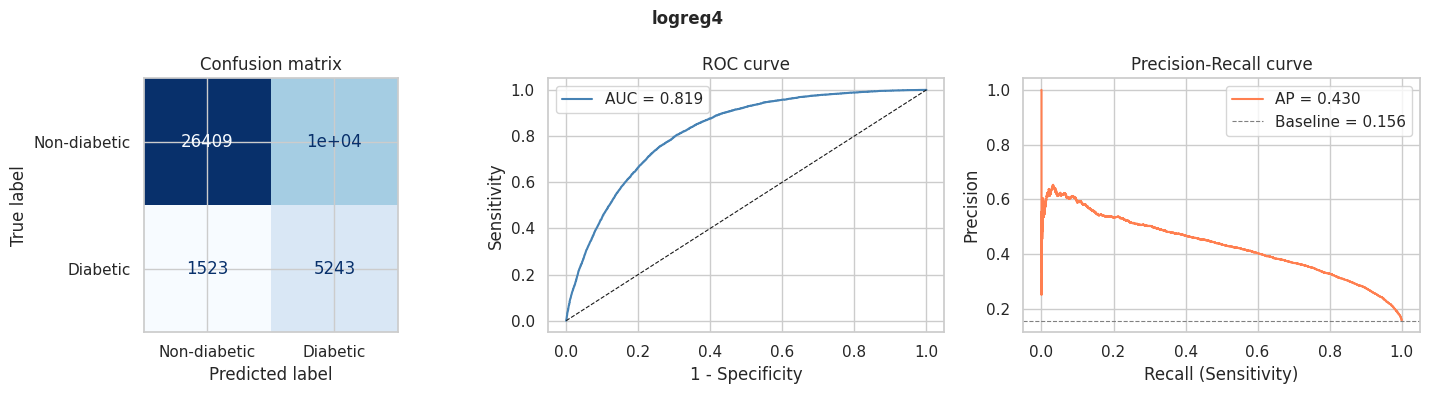

In [95]:
logreg4 = IMB_Pipeline([
    ('preprocessor', preprocessor()),
    ('oversample', SMOTE(random_state=42)),
    ('lr', LogisticRegression(random_state=42, class_weight='balanced'))
])


logreg4.fit(X_train, y_train)

lr_pred4 = logreg4.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, lr_pred4)}")
# acc = accuracy_score(y_test, lr_pred3)
tn, fp, fn, tp = confusion_matrix(y_test, lr_pred4).ravel()
lr_prob4 = logreg4.predict_proba(X_test)[:, 1]

metrics = evaluate_model('logreg4', y_test, lr_pred4, lr_prob4)

### XGB

Accuracy: 0.7193898679427598

────────────────────────────────────────
  xgb
────────────────────────────────────────
  accuracy           0.7194
  sensitivity        0.7993
  specificity        0.7047
  ppv                0.3329
  npv                0.9501
  f1                 0.4700
  roc_auc            0.8257
  avg_precision      0.4556
  brier              0.1764


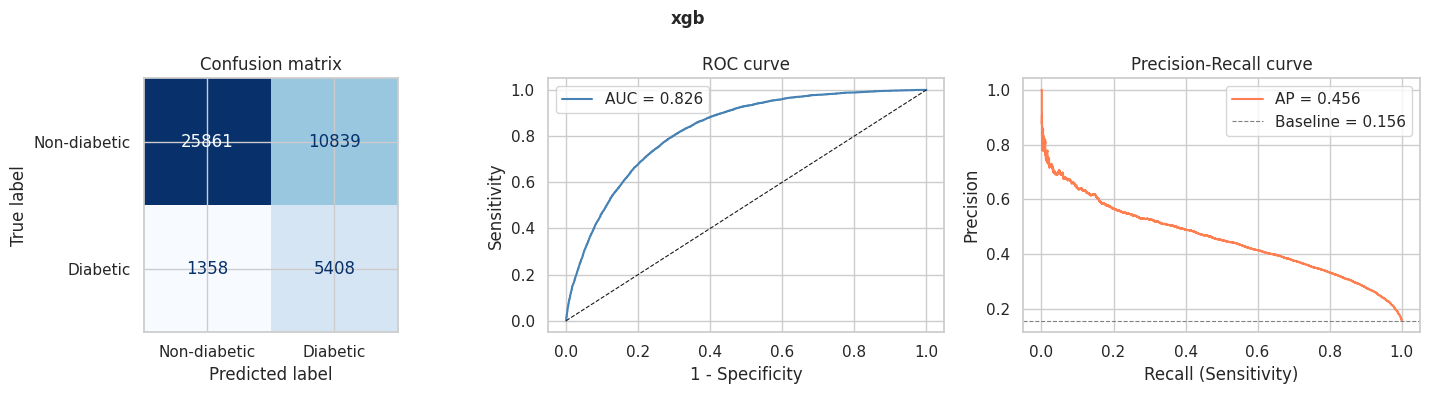

In [91]:
xgb = Pipeline([
    ('preprocessor', preprocessor()),
    ('xgb', XGBClassifier(
        scale_pos_weight=734009/135310,
        random_state=42,
        n_jobs=-1
    ))
])

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, xgb_pred)}")
tn, fp, fn, tp = confusion_matrix(y_test, xgb_pred).ravel()

metrics = evaluate_model('xgb', y_test, xgb_pred, xgb_prob)

Accuracy: 0.6773800211659688

────────────────────────────────────────
  xgb2
────────────────────────────────────────
  accuracy           0.6774
  sensitivity        0.8448
  specificity        0.6465
  ppv                0.3058
  npv                0.9576
  f1                 0.4491
  roc_auc            0.8199
  avg_precision      0.4416
  brier              0.2050


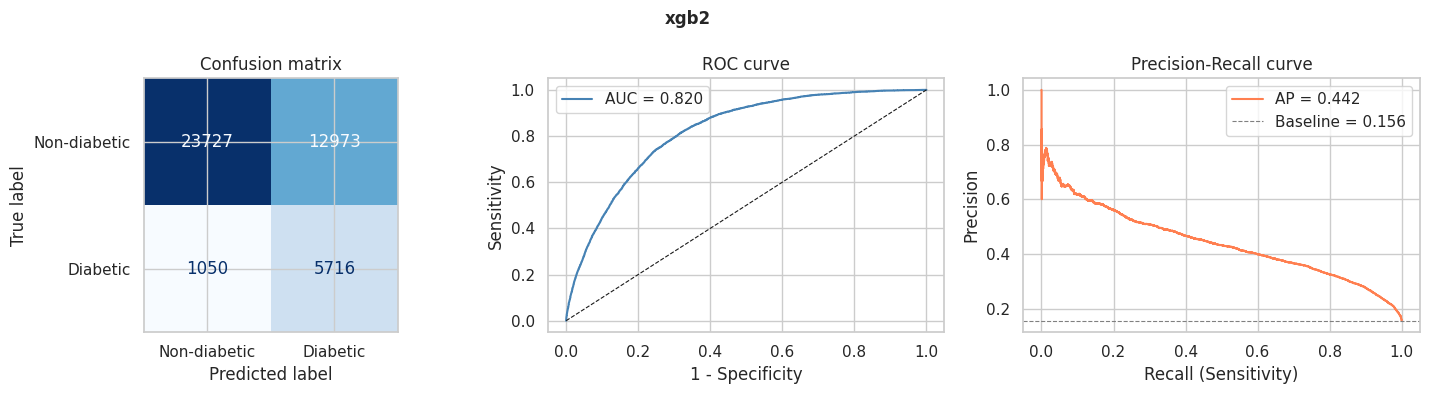

In [97]:
# try oversampling on xgb
xgb2 = IMB_Pipeline([
    ('preprocessor', preprocessor()),
    ('oversample', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        scale_pos_weight=734009/135310,
        random_state=42,
        n_jobs=-1
    ))
])

xgb2.fit(X_train, y_train)

xgb_pred2 = xgb2.predict(X_test)
xgb_prob2 = xgb2.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, xgb_pred2)}")
tn, fp, fn, tp = confusion_matrix(y_test, xgb_pred2).ravel()

metrics = evaluate_model('xgb2', y_test, xgb_pred2, xgb_prob2)

Oversampling did not improve performance.

### Try Multiple Models

In [3]:
# compiled preprocessing
def wrangle(filepath="../datasets/cleaned_data.csv"):
    # read cleaned data
    df = pd.read_csv(filepath)

    # Define the explicit numeric mapping (1 = Low, 2 = Medium, 3 = High)
    income_tier_map = {
        # Low Income Tier (1)
        '<$10,000': 1,
        '$10,000 - <$15,000': 1,
        '$15,000 - <$20,000': 1,
        '$20,000 - <$25,000': 1,
        
        # Medium Income Tier (2)
        '$25,000 - <$35,000': 2,
        '$35,000 - <$50,000': 2,
        '$50,000 - <$75,000': 2,
        
        # High Income Tier (3)
        '$75,000 - <$100,000': 3,
        '$100,000 - <$150,000': 3,
        '$150,000 - <$20,000': 3,  # Captures the exact string variation in list
        '$150,000 - <$200,000': 3,
        '$200,000+': 3
    }

    # 2. Apply the mapping to create the new numerical feature
    df['socioeconomic_tier'] = df['income_level'].map(income_tier_map)

    # invert direction of general health so that higher values mean better health
    df.gen_health = 6 - df.gen_health

    # invert direction of last check up so that higher values mean better checkup attitude
    df.l_checkup = 6 - df.l_checkup

    # drop redundant and low cardinality features
    to_drop = ['year', 'age_group', 'race', 'weight', 'height', 'education_level', 'income_level',
            'income', 'had_coronary_heart_disease', 'general_health', 'last_checkup']
    df.drop(columns=to_drop, inplace=True)

    # convert True/False columns (boolean) to integers
    t_f_cols = ['smoked_100_cigarettes', 'drinks_alcohol', 'had_stroke', 'had_heart_attack',
                'exercise', 'cost_barrier']
    for col in t_f_cols:
        df[col] = df[col].astype('int8')

    
    # include feature engineering steps

    # collapose target
    df['diabetes'] = df['diabetes'].map({'Non-diabetic': 0, 'Pre-diabetic': 1, 'Diabetic': 1})

    # collapse marital status
    df['marital_status'] = df['marital_status'].map({
        'Married': 'Married/Cohabiting',
        'A member of an unmarried couple': 'Married/Cohabiting',
        'Never married': 'Single',
        'Divorced': 'Previously Married',
        'Separated': 'Previously Married',
        'Widowed': 'Previously Married'
    })

    # collapse employment status
    df['employment_status'] = df['employment_status'].map({
        'Employed for wages': 'Employed',
        'Self-employed': 'Employed',
        'Retired': 'Retired',
        'Out of work for less that 1 year': 'Unemployed',
        'Out of work for more than 1 year': 'Unemployed',
        'A homemaker': 'Student/Homemaker',
        'A student': 'Student/Homemaker',
        'Unable to work': 'Unable to work'
    })

    # collapse personal doctor count
    df['has_personal_doctor'] = df['has_personal_doctor'].map({
        'Yes, only one': 1, # Yes
        'More than one': 1, # Yes
        "No": 0 # No
    })

    return df


df = wrangle()
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   age                    869319 non-null  float64
 1   sex                    869319 non-null  str    
 2   bmi                    869319 non-null  float64
 3   marital_status         869319 non-null  str    
 4   education              869319 non-null  float64
 5   employment_status      869319 non-null  str    
 6   gen_health             869319 non-null  float64
 7   physical_health_days   869319 non-null  float64
 8   mental_health_days     869319 non-null  float64
 9   exercise               869319 non-null  int8   
 10  smoked_100_cigarettes  869319 non-null  int8   
 11  drinks_alcohol         869319 non-null  int8   
 12  high_bp                869319 non-null  str    
 13  had_stroke             869319 non-null  int8   
 14  had_heart_attack       869319 non-null  int8   

,age,sex,bmi,marital_status,education,employment_status,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,cost_barrier,l_checkup,has_personal_doctor,diabetes,socioeconomic_tier
0,5.0,Female,35.51,Single,5.0,Student/Homemaker,4.0,0.0,30.0,0,1,0,Yes,0,0,0,5.0,1,0,1
1,9.0,Male,24.21,Previously Married,5.0,Unable to work,2.0,3.0,12.0,1,1,0,Yes,0,0,0,5.0,0,0,1
2,6.0,Female,27.96,Previously Married,4.0,Employed,3.0,0.0,10.0,1,1,1,Yes,0,0,0,5.0,1,1,1
3,6.0,Male,30.68,Married/Cohabiting,4.0,Employed,4.0,0.0,0.0,1,1,0,No,0,0,0,5.0,0,0,3
4,10.0,Male,37.33,Previously Married,4.0,Retired,2.0,30.0,0.0,0,1,0,Yes,1,0,0,5.0,1,1,1


In [4]:
df.to_csv("../datasets/final_model_data.csv", index=False)

In [10]:
df = pd.read_csv("../datasets/final_model_data.csv")
df.head()

,age,sex,bmi,marital_status,education,employment_status,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,cost_barrier,l_checkup,has_personal_doctor,diabetes,socioeconomic_tier
0,5.0,Female,35.51,Single,5.0,Student/Homemaker,4.0,0.0,30.0,0,1,0,Yes,0,0,0,5.0,1,0,1
1,9.0,Male,24.21,Previously Married,5.0,Unable to work,2.0,3.0,12.0,1,1,0,Yes,0,0,0,5.0,0,0,1
2,6.0,Female,27.96,Previously Married,4.0,Employed,3.0,0.0,10.0,1,1,1,Yes,0,0,0,5.0,1,1,1
3,6.0,Male,30.68,Married/Cohabiting,4.0,Employed,4.0,0.0,0.0,1,1,0,No,0,0,0,5.0,0,0,3
4,10.0,Male,37.33,Previously Married,4.0,Retired,2.0,30.0,0.0,0,1,0,Yes,1,0,0,5.0,1,1,1


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   age                    869319 non-null  float64
 1   sex                    869319 non-null  str    
 2   bmi                    869319 non-null  float64
 3   marital_status         869319 non-null  str    
 4   education              869319 non-null  float64
 5   employment_status      869319 non-null  str    
 6   gen_health             869319 non-null  float64
 7   physical_health_days   869319 non-null  float64
 8   mental_health_days     869319 non-null  float64
 9   exercise               869319 non-null  int64  
 10  smoked_100_cigarettes  869319 non-null  int64  
 11  drinks_alcohol         869319 non-null  int64  
 12  high_bp                869319 non-null  str    
 13  had_stroke             869319 non-null  int64  
 14  had_heart_attack       869319 non-null  int64  

In [6]:
target = 'diabetes'

y = df[target]
X = df.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)

print(f"Training...\nFeatures:  {len(X_train)}\tTarget:  {len(y_train)}")
print(f"Testing...\nFeatures:  {len(X_test)}\tTarget:  {len(y_test)}")

Training...
Features:  825853	Target:  825853
Testing...
Features:  43466	Target:  43466


In [11]:
# build column transformer
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(exclude='number').columns.tolist()

In [9]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', random_state=42),
    # 'Random Forest':       RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    # 'Extra Trees':         ExtraTreesClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'AdaBoost':            AdaBoostClassifier(random_state=42),
    'XGBoost':             XGBClassifier(scale_pos_weight=734009/135310, random_state=42, n_jobs=-1),
    'LightGBM':            LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'Bagging':             BaggingClassifier(random_state=42, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_jobs=-1),
}

Fitting Logistic Regression...

────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────
  accuracy           0.7274
  sensitivity        0.7774
  specificity        0.7182
  ppv                0.3371
  npv                0.9459
  f1                 0.4703
  roc_auc            0.8201
  avg_precision      0.4315
  brier              0.1787


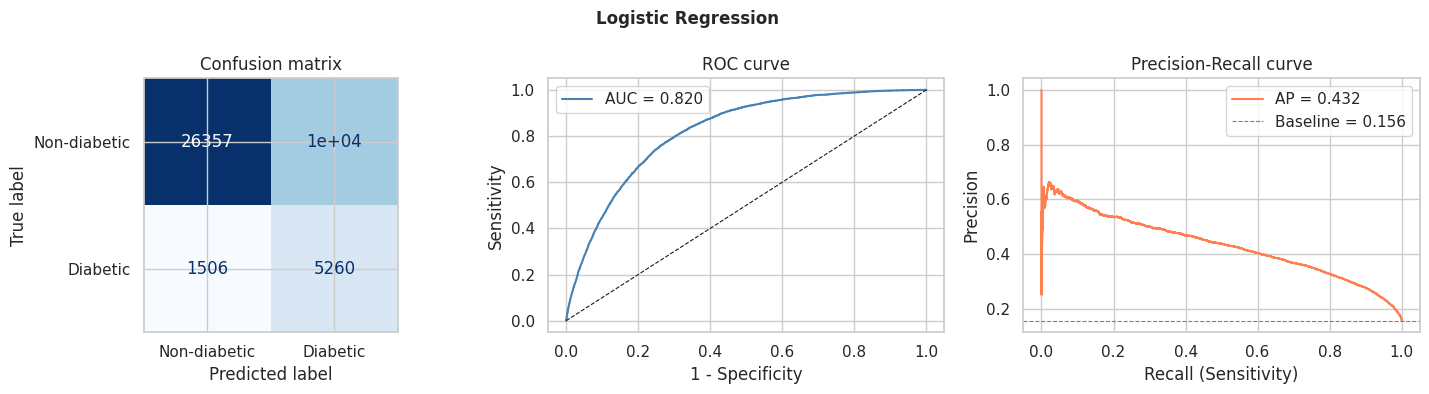

Fitting Decision Tree...

────────────────────────────────────────
  Decision Tree
────────────────────────────────────────
  accuracy           0.7841
  sensitivity        0.3070
  specificity        0.8720
  ppv                0.3067
  npv                0.8722
  f1                 0.3068
  roc_auc            0.5900
  avg_precision      0.2039
  brier              0.2140


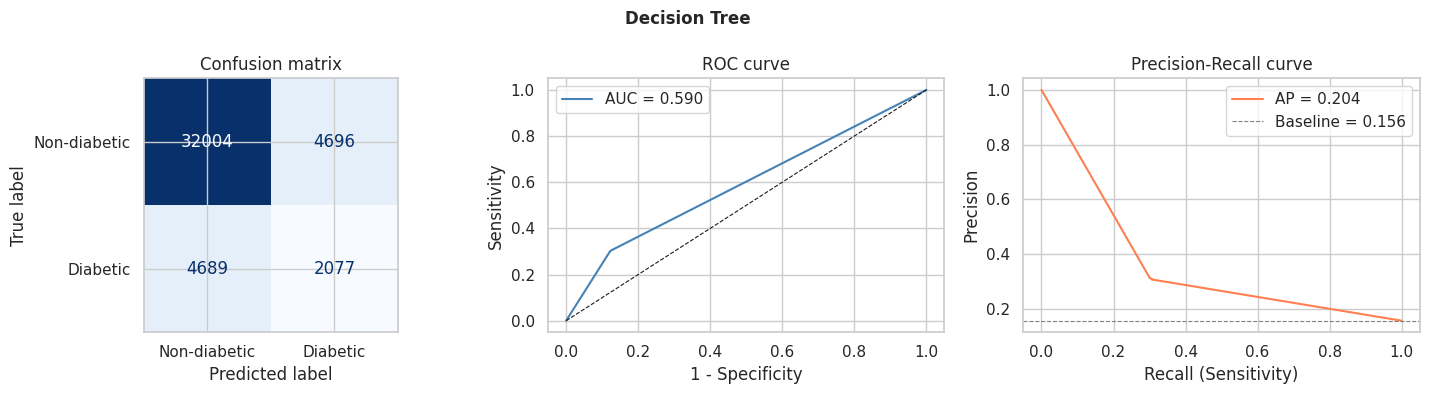

Fitting Gradient Boosting...

────────────────────────────────────────
  Gradient Boosting
────────────────────────────────────────
  accuracy           0.8520
  sensitivity        0.1881
  specificity        0.9744
  ppv                0.5755
  npv                0.8668
  f1                 0.2836
  roc_auc            0.8262
  avg_precision      0.4546
  brier              0.1050


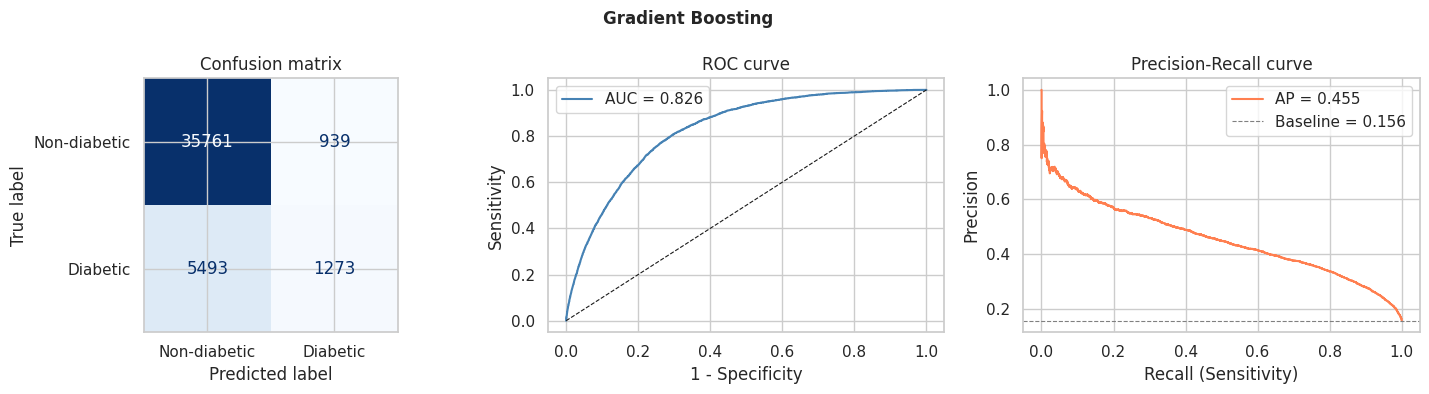

Fitting AdaBoost...

────────────────────────────────────────
  AdaBoost
────────────────────────────────────────
  accuracy           0.8505
  sensitivity        0.2053
  specificity        0.9694
  ppv                0.5529
  npv                0.8687
  f1                 0.2994
  roc_auc            0.8211
  avg_precision      0.4417
  brier              0.1541


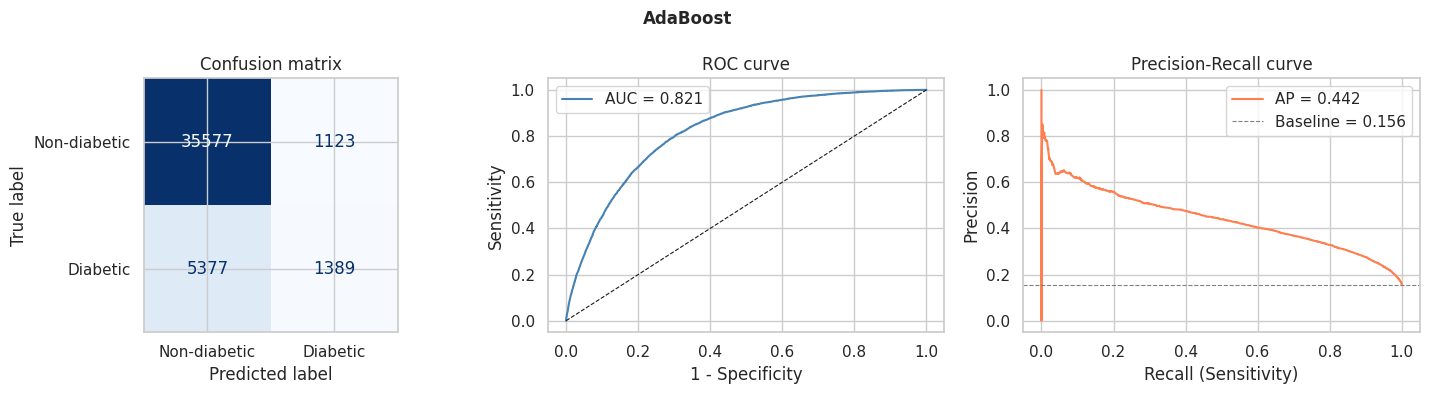

Fitting XGBoost...

────────────────────────────────────────
  XGBoost
────────────────────────────────────────
  accuracy           0.7190
  sensitivity        0.8009
  specificity        0.7039
  ppv                0.3328
  npv                0.9504
  f1                 0.4702
  roc_auc            0.8254
  avg_precision      0.4526
  brier              0.1768


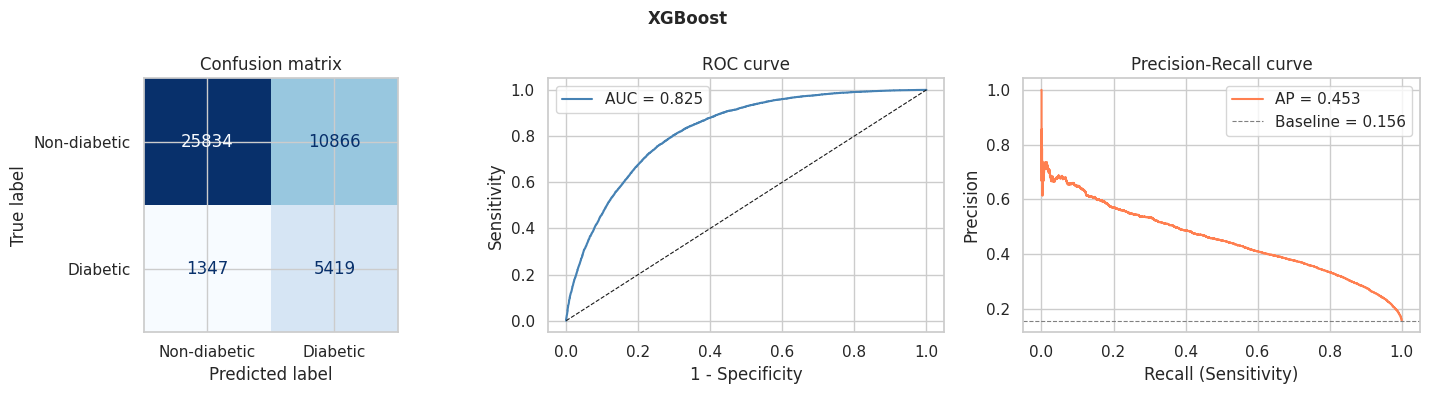

Fitting LightGBM...
[LightGBM] [Info] Number of positive: 128544, number of negative: 697309
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 825853, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



────────────────────────────────────────
  LightGBM
────────────────────────────────────────
  accuracy           0.7174
  sensitivity        0.8095
  specificity        0.7004
  ppv                0.3325
  npv                0.9522
  f1                 0.4714
  roc_auc            0.8271
  avg_precision      0.4575
  brier              0.1775


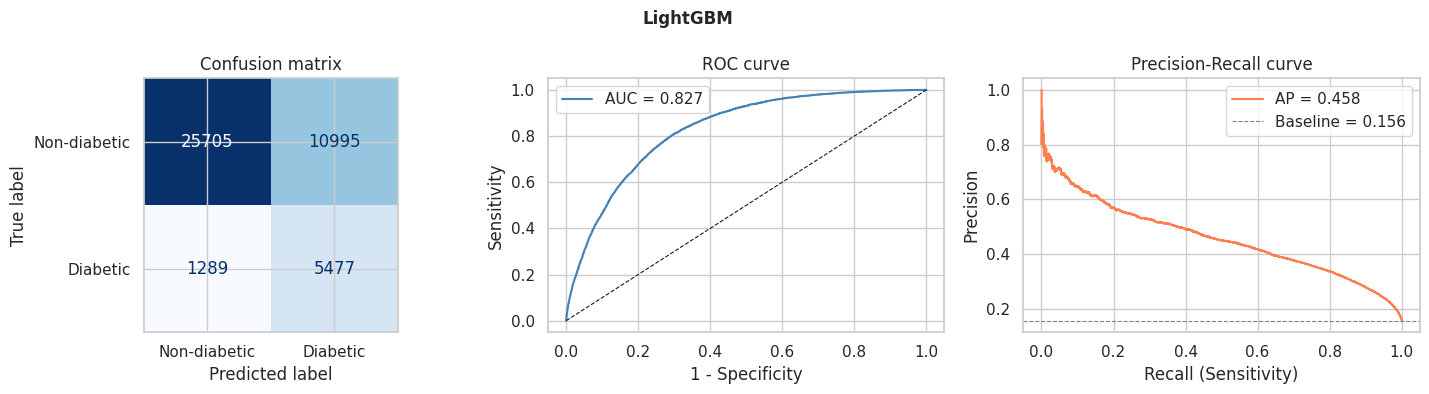

Fitting Bagging...

────────────────────────────────────────
  Bagging
────────────────────────────────────────
  accuracy           0.8321
  sensitivity        0.2100
  specificity        0.9468
  ppv                0.4213
  npv                0.8667
  f1                 0.2803
  roc_auc            0.7473
  avg_precision      0.3238
  brier              0.1256


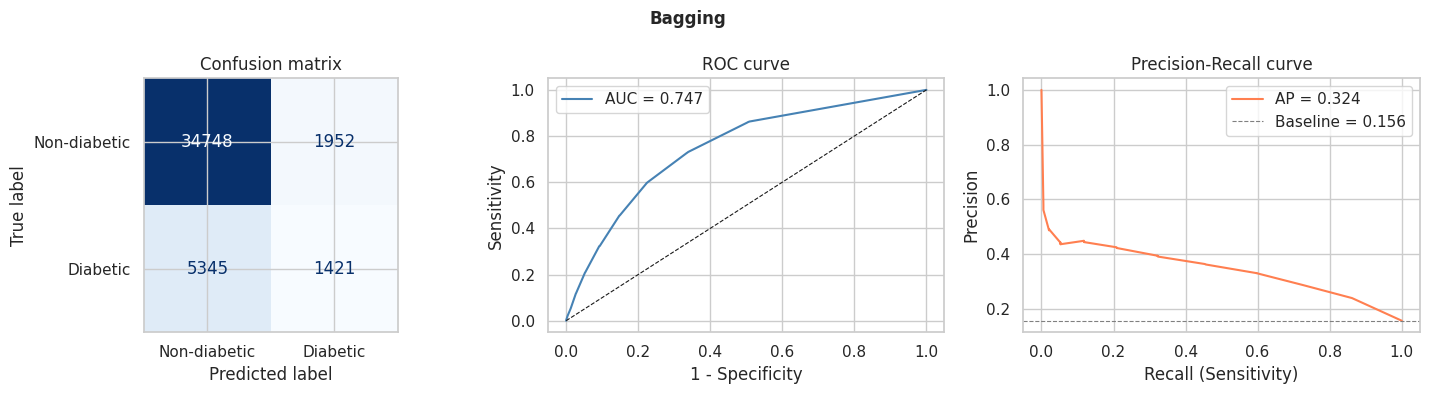

Fitting KNN...

────────────────────────────────────────
  KNN
────────────────────────────────────────
  accuracy           0.8292
  sensitivity        0.2406
  specificity        0.9378
  ppv                0.4162
  npv                0.8701
  f1                 0.3049
  roc_auc            0.7303
  avg_precision      0.3077
  brier              0.1266


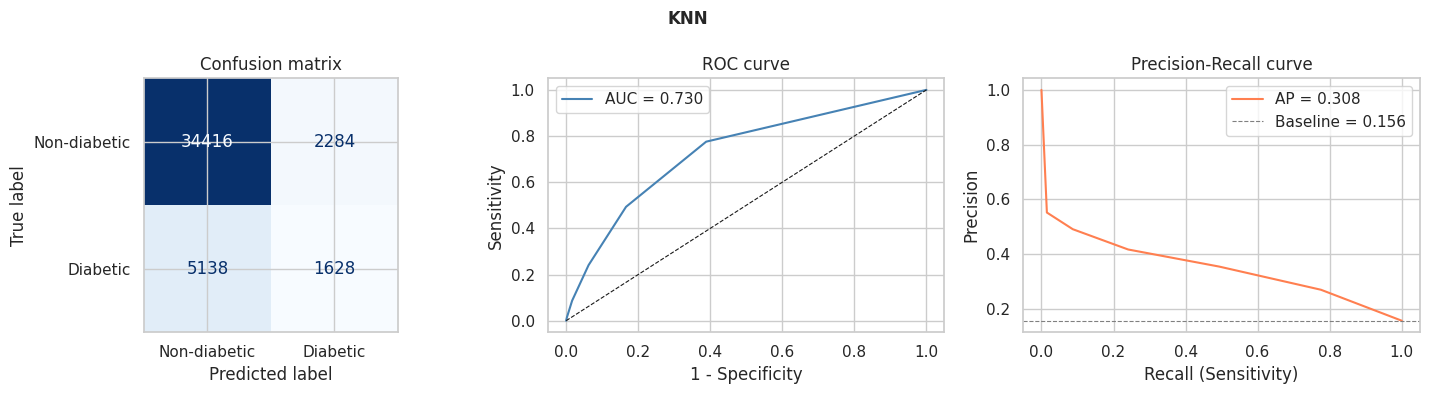

                     accuracy  sensitivity  specificity       ppv       npv        f1   roc_auc  avg_precision     brier
model                                                                                                                   
LightGBM             0.717388     0.809489     0.700409  0.332504  0.952249  0.471383  0.827146       0.457520  0.177537
XGBoost              0.719022     0.800916     0.703924  0.332760  0.950443  0.470175  0.825358       0.452558  0.176827
Logistic Regression  0.727396     0.777416     0.718174  0.337115  0.945950  0.470294  0.820109       0.431526  0.178699
Decision Tree        0.784084     0.306976     0.872044  0.306659  0.872210  0.306817  0.590009       0.203869  0.214017
KNN                  0.829246     0.240615     0.937766  0.416155  0.870102  0.304926  0.730254       0.307724  0.126590
Bagging              0.832122     0.210021     0.946812  0.421287  0.866685  0.280304  0.747326       0.323780  0.125624
AdaBoost             0.850458   

In [10]:
results = []

for name, model in models.items():
    print(f"Fitting {name}...")

    pipeline = Pipeline([
        ('preprocessor', preprocessor()),
        (f'{name}', model)
    ])

    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    metrics = evaluate_model(name, y_test, y_pred, y_prob)
    results.append(metrics)

results_df = pd.DataFrame(results).set_index('model').sort_values('sensitivity', ascending=False)
print(results_df)

In [11]:
results_df.to_csv('../model_building/results.csv', index=True)

#### Top performing models
(optimizing for Sensitivity, i.e. catch as many diabetics as possible)

- LightGBM
- XGBoost
- Logistic Regression

### Perform Grid Search on these

In [12]:
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   age                    869319 non-null  float64
 1   sex                    869319 non-null  str    
 2   bmi                    869319 non-null  float64
 3   marital_status         869319 non-null  str    
 4   education              869319 non-null  float64
 5   employment_status      869319 non-null  str    
 6   gen_health             869319 non-null  float64
 7   physical_health_days   869319 non-null  float64
 8   mental_health_days     869319 non-null  float64
 9   exercise               869319 non-null  int64  
 10  smoked_100_cigarettes  869319 non-null  int64  
 11  drinks_alcohol         869319 non-null  int64  
 12  high_bp                869319 non-null  str    
 13  had_stroke             869319 non-null  int64  
 14  had_heart_attack       869319 non-null  int64  

,age,sex,bmi,marital_status,education,employment_status,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,cost_barrier,l_checkup,has_personal_doctor,diabetes,socioeconomic_tier
0,5.0,Female,35.51,Single,5.0,Student/Homemaker,4.0,0.0,30.0,0,1,0,Yes,0,0,0,5.0,1,0,1
1,9.0,Male,24.21,Previously Married,5.0,Unable to work,2.0,3.0,12.0,1,1,0,Yes,0,0,0,5.0,0,0,1
2,6.0,Female,27.96,Previously Married,4.0,Employed,3.0,0.0,10.0,1,1,1,Yes,0,0,0,5.0,1,1,1
3,6.0,Male,30.68,Married/Cohabiting,4.0,Employed,4.0,0.0,0.0,1,1,0,No,0,0,0,5.0,0,0,3
4,10.0,Male,37.33,Previously Married,4.0,Retired,2.0,30.0,0.0,0,1,0,Yes,1,0,0,5.0,1,1,1


In [18]:
sample_df = df.sample(200000, random_state=42)
sample_df.diabetes.sum() / len(sample_df)

np.float64(0.15623)

In [19]:
target = 'diabetes'

y = sample_df[target]
X = sample_df.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)

print(f"Training...\nFeatures:  {len(X_train)}\tTarget:  {len(y_train)}")
print(f"Testing...\nFeatures:  {len(X_test)}\tTarget:  {len(y_test)}")

Training...
Features:  190000	Target:  190000
Testing...
Features:  10000	Target:  10000



Grid searching Logistic Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params : {'Logistic Regression__C': 0.01, 'Logistic Regression__solver': 'lbfgs'}
Best CV recall: 0.7667

────────────────────────────────────────
  Logistic Regression (tuned)
────────────────────────────────────────
  accuracy           0.7203
  sensitivity        0.7862
  specificity        0.7081
  ppv                0.3327
  npv                0.9471
  f1                 0.4675
  roc_auc            0.8191
  avg_precision      0.4375
  brier              0.1824


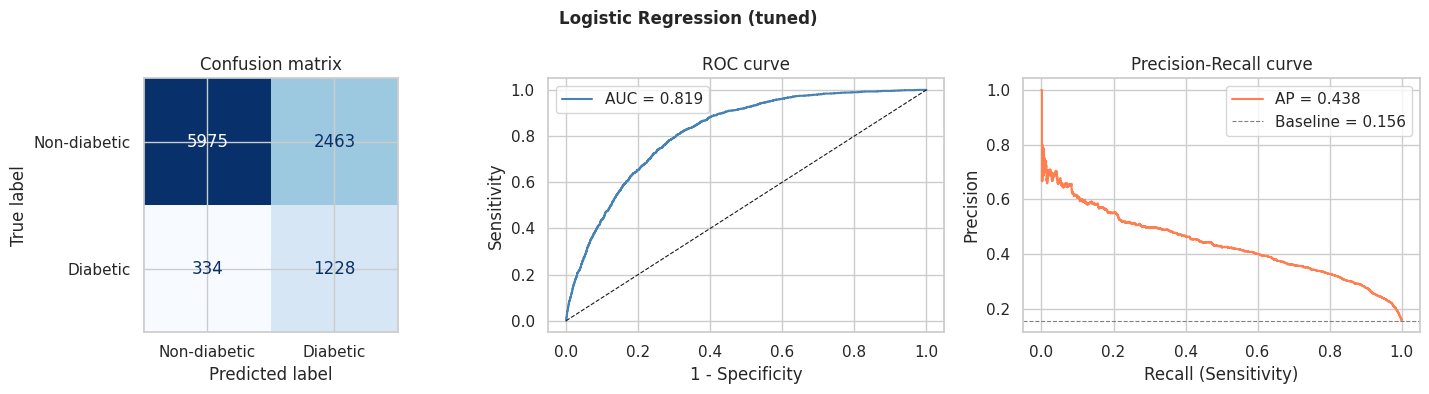


Grid searching XGBoost...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best params : {'XGBoost__learning_rate': 0.01, 'XGBoost__max_depth': 5, 'XGBoost__n_estimators': 300, 'XGBoost__subsample': 0.8}
Best CV recall: 0.7948

────────────────────────────────────────
  XGBoost (tuned)
────────────────────────────────────────
  accuracy           0.7033
  sensitivity        0.8111
  specificity        0.6833
  ppv                0.3217
  npv                0.9513
  f1                 0.4606
  roc_auc            0.8208
  avg_precision      0.4537
  brier              0.1826


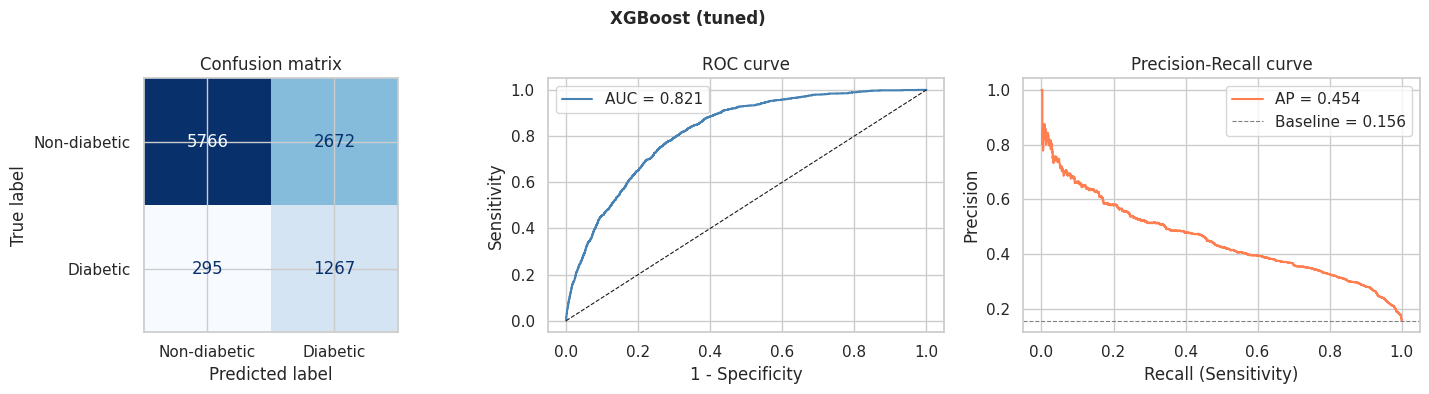


Grid searching LightGBM...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Number of positive: 19790, number of negative: 106877
[LightGBM] [Info] Number of positive: 19789, number of negative: 106877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.367486 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.399802 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126667, number of used features: 28
[LightGBM] [Info] Number of data points in the train set: 126666, number of used features: 28
[LightGBM] [Info] Number of positive: 19789, number of negativ

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19790, number of negative: 106877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.527330 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126667, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 19789, number of negative: 106877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.673206 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126666, number of used features: 28
[LightGBM] [Info

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19789, number of negative: 106878
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.637613 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126667, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19790, number of negative: 106877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.670641 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126667, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19789, number of negative: 106877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.563512 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126666, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19789, number of negative: 106878
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.598696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126667, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19790, number of negative: 106877
[LightGBM] [Info] Number of positive: 19789, number of negative: 106877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.637246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126667, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.620623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126666, number of used features: 28
[LightGBM] [Info

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19789, number of negative: 106878
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.598625 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126667, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 19790, number of negative: 106877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.544651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126667, number of used features: 28
[LightGBM] [Info] 

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19789, number of negative: 106877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.559404 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126666, number of used features: 28
[LightGBM] [Info] Number of positive: 19789, number of negative: 106878
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.643139 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126667, number of used features: 28
[LightGBM] [Info

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19790, number of negative: 106877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.475999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126667, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19789, number of negative: 106877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.665872 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126666, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19789, number of negative: 106878
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.619052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126667, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19790, number of negative: 106877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.596629 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 126667, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does n

[LightGBM] [Info] Number of positive: 29684, number of negative: 160316
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039995 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 190000, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Best params : {'LightGBM__learning_rate': 0.05, 'LightGBM__n_estimators': 300, 'LightGBM__num_leaves': 31}
Best CV recall: 0.7858

────────────────────────────────────────
  LightGBM (tuned)
────────────────────────────────────────
  accuracy           0.7115
  sensitivity        0.8060
  specificity        0.6940
  ppv                0.3278
  npv                0.9508
  f1                 0.4660
  roc_auc            0.8239
  avg_precisi

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


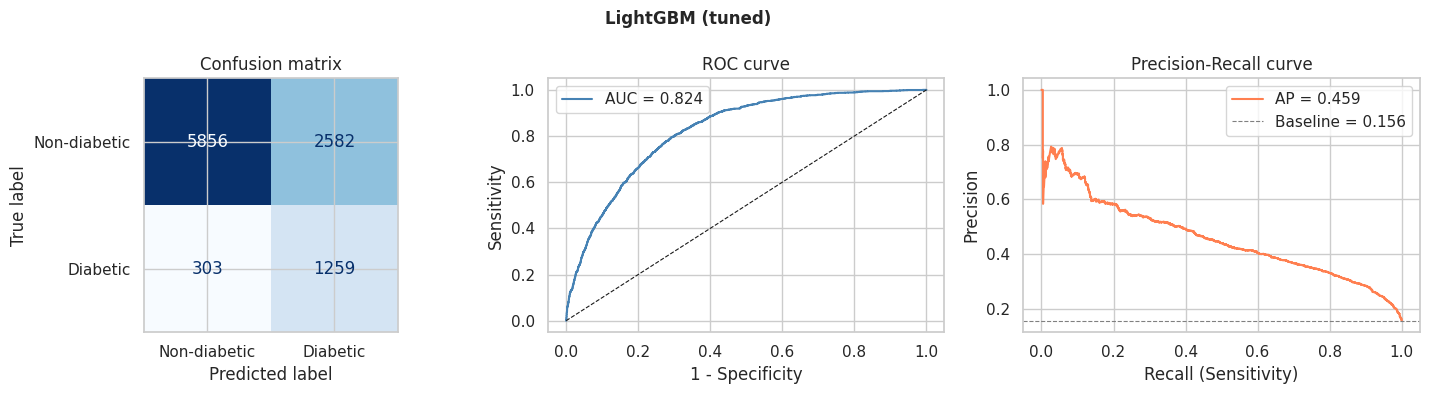

                             accuracy  sensitivity  specificity       ppv       npv        f1   roc_auc  avg_precision     brier                                                                                                         best_params
model                                                                                                                                                                                                                                               
XGBoost (tuned)                0.7033     0.811140     0.683337  0.321655  0.951328  0.460644  0.820789       0.453694  0.182615  {'XGBoost__learning_rate': 0.01, 'XGBoost__max_depth': 5, 'XGBoost__n_estimators': 300, 'XGBoost__subsample': 0.8}
LightGBM (tuned)               0.7115     0.806018     0.694003  0.327779  0.950804  0.466037  0.823906       0.458559  0.179721                        {'LightGBM__learning_rate': 0.05, 'LightGBM__n_estimators': 300, 'LightGBM__num_leaves': 31}
Logistic Regression 

In [20]:
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(exclude='number').columns.tolist()

param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
        'params': {
            'Logistic Regression__C': [0.01, 0.1, 1, 10],
            'Logistic Regression__solver': ['lbfgs', 'saga'],
        }
    },
    'XGBoost': {
        'model': XGBClassifier(scale_pos_weight=734009/135310, random_state=42, n_jobs=-1),
        'params': {
            'XGBoost__n_estimators': [100, 300, 500],
            'XGBoost__max_depth': [3, 5, 7],
            'XGBoost__learning_rate': [0.01, 0.1, 0.3],
            'XGBoost__subsample': [0.8, 1.0],
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        'params': {
            'LightGBM__n_estimators': [300, 500],
            'LightGBM__learning_rate': [0.05, 0.1],
            'LightGBM__num_leaves': [31, 63],
        }
    }
}

gs_results = []

for name, config in param_grids.items():
    print(f"\nGrid searching {name}...")

    pipeline = Pipeline([
        ('preprocessor', preprocessor()),
        (name, config['model'])
    ])

    gs = GridSearchCV(
        pipeline,
        param_grid=config['params'],
        scoring='recall',       # optimising for sensitivity
        cv=3,
        n_jobs=-1,
        verbose=1
    )

    gs.fit(X_train, y_train)

    print(f"Best params : {gs.best_params_}")
    print(f"Best CV recall: {gs.best_score_:.4f}")

    y_pred = gs.predict(X_test)
    y_prob = gs.predict_proba(X_test)[:, 1]
    metrics = evaluate_model(f"{name} (tuned)", y_test, y_pred, y_prob)
    metrics['best_params'] = gs.best_params_

    gs_results.append(metrics)

gs_df = pd.DataFrame(gs_results).set_index('model')
print(gs_df.sort_values('sensitivity', ascending=False))

In [21]:
gs_df.to_csv("gs_results.csv", index=True)

### Retrain best performing models with full data

In [32]:
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   age                    869319 non-null  float64
 1   sex                    869319 non-null  str    
 2   bmi                    869319 non-null  float64
 3   marital_status         869319 non-null  str    
 4   education              869319 non-null  float64
 5   employment_status      869319 non-null  str    
 6   gen_health             869319 non-null  float64
 7   physical_health_days   869319 non-null  float64
 8   mental_health_days     869319 non-null  float64
 9   exercise               869319 non-null  int64  
 10  smoked_100_cigarettes  869319 non-null  int64  
 11  drinks_alcohol         869319 non-null  int64  
 12  high_bp                869319 non-null  str    
 13  had_stroke             869319 non-null  int64  
 14  had_heart_attack       869319 non-null  int64  

,age,sex,bmi,marital_status,education,employment_status,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,cost_barrier,l_checkup,has_personal_doctor,diabetes,socioeconomic_tier
0,5.0,Female,35.51,Single,5.0,Student/Homemaker,4.0,0.0,30.0,0,1,0,Yes,0,0,0,5.0,1,0,1
1,9.0,Male,24.21,Previously Married,5.0,Unable to work,2.0,3.0,12.0,1,1,0,Yes,0,0,0,5.0,0,0,1
2,6.0,Female,27.96,Previously Married,4.0,Employed,3.0,0.0,10.0,1,1,1,Yes,0,0,0,5.0,1,1,1
3,6.0,Male,30.68,Married/Cohabiting,4.0,Employed,4.0,0.0,0.0,1,1,0,No,0,0,0,5.0,0,0,3
4,10.0,Male,37.33,Previously Married,4.0,Retired,2.0,30.0,0.0,0,1,0,Yes,1,0,0,5.0,1,1,1


In [22]:
full_retrain_metrics = []

In [23]:
target = 'diabetes'

y = df[target]
X = df.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)

print(f"Training...\nFeatures:  {len(X_train)}\tTarget:  {len(y_train)}")
print(f"Testing...\nFeatures:  {len(X_test)}\tTarget:  {len(y_test)}")

Training...
Features:  825853	Target:  825853
Testing...
Features:  43466	Target:  43466


[LightGBM] [Info] Number of positive: 128544, number of negative: 697309
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 825853, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.717204251598951

────────────────────────────────────────
  best_lgbm
────────────────────────────────────────
  accuracy           0.7172
  sensitivity        0.8083
  specificity        0.7004
  ppv                0.3322
  npv                0.9520
  f1                 0.4709
  roc_auc            0.8274
  avg_precision      0.4574
  brier              0.1773


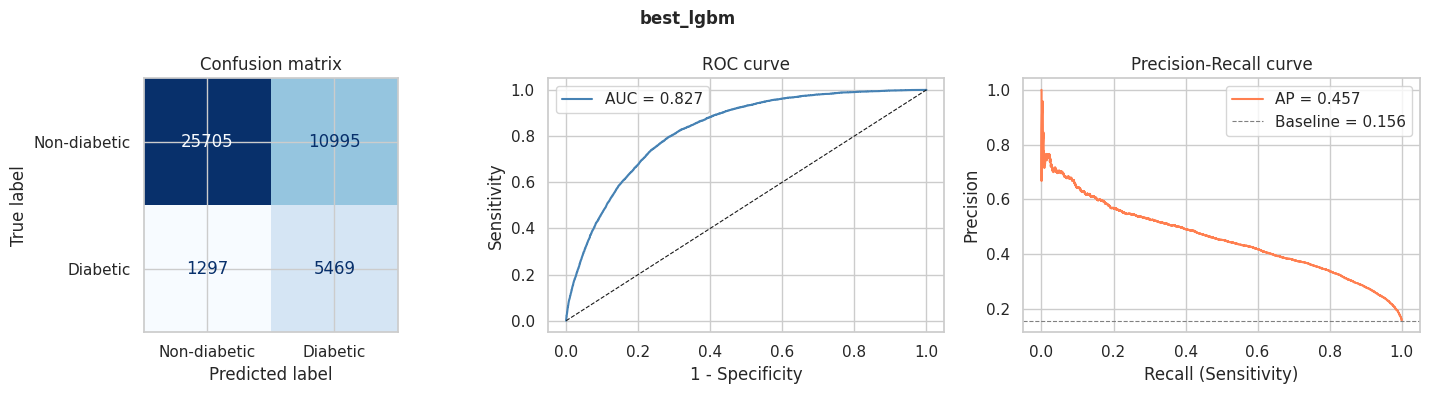

In [24]:
lgbm_model = Pipeline([
    ('preprocessor', preprocessor()),
    ('best_lgbm', LGBMClassifier(
        learning_rate=0.05,
        n_estimators=300,
        num_leaves=31,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

lgbm_model.fit(X_train, y_train)

best_lgbm_pred = lgbm_model.predict(X_test)
best_lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, best_lgbm_pred)}")
tn, fp, fn, tp = confusion_matrix(y_test, best_lgbm_pred).ravel()

metrics = evaluate_model('best_lgbm', y_test, best_lgbm_pred, best_lgbm_prob)

full_retrain_metrics.append(metrics)

In [29]:
# save lightgbm model
joblib.dump(lgbm_model, "models/lgbm_model.pkl")

['models/lgbm_model.pkl']

Accuracy: 0.7132471356922652

────────────────────────────────────────
  best_xgb
────────────────────────────────────────
  accuracy           0.7132
  sensitivity        0.8071
  specificity        0.6959
  ppv                0.3286
  npv                0.9514
  f1                 0.4670
  roc_auc            0.8240
  avg_precision      0.4499
  brier              0.1788


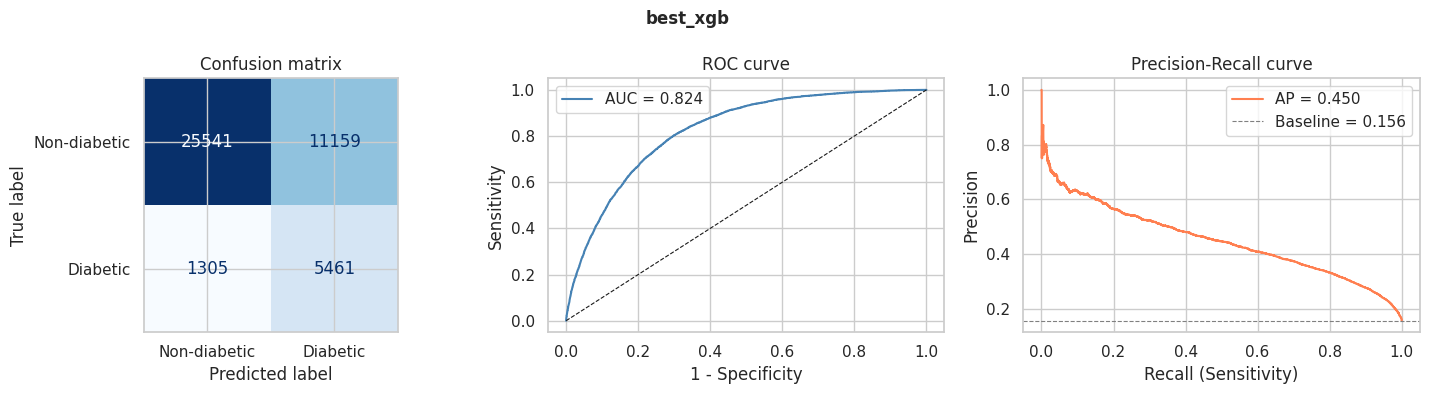

In [26]:
# retrain XGBoost model to save

xgb_model = Pipeline([
    ('preprocessor', preprocessor()),
    ('xgb', XGBClassifier(scale_pos_weight=734009/135310, learning_rate=0.01, max_depth=5,\
                            n_estimators=300, subsample=0.8, random_state=42))
    # ('xgb', XGBClassifier(random_state=42))


])

xgb_model.fit(X_train, y_train)

best_xgb_pred = xgb_model.predict(X_test)
best_xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, best_xgb_pred)}")
tn, fp, fn, tp = confusion_matrix(y_test, best_xgb_pred).ravel()

metrics = evaluate_model('best_xgb', y_test, best_xgb_pred, best_xgb_prob)

full_retrain_metrics.append(metrics)

In [27]:
# save xgb model
joblib.dump(xgb_model, "models/xgb_model.pkl")

['models/xgb_model.pkl']

Accuracy: 0.7273961257074495

────────────────────────────────────────
  best_lr
────────────────────────────────────────
  accuracy           0.7274
  sensitivity        0.7776
  specificity        0.7181
  ppv                0.3371
  npv                0.9460
  f1                 0.4703
  roc_auc            0.8201
  avg_precision      0.4315
  brier              0.1787


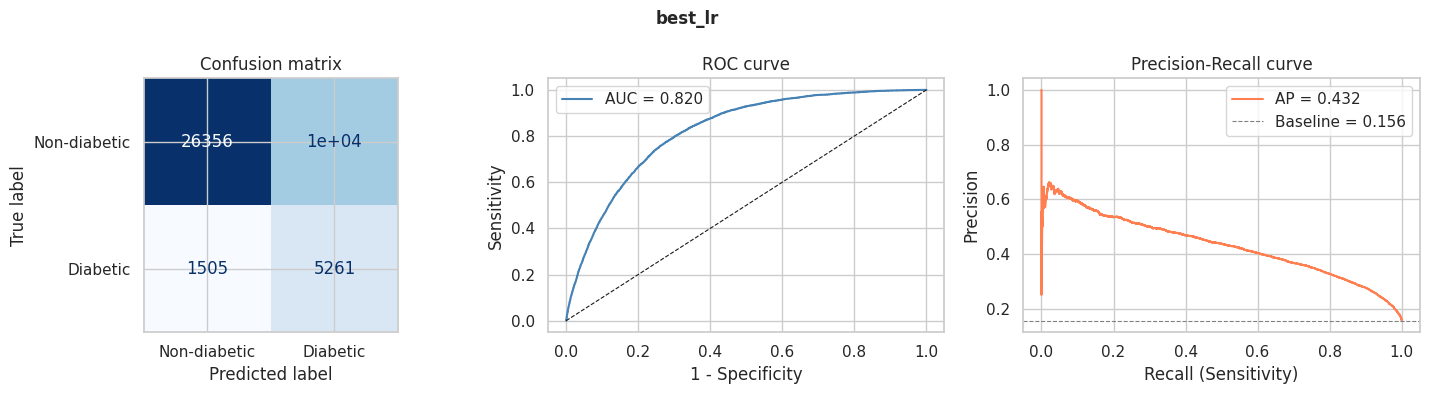

['models/logreg_model.pkl']

In [28]:
# retrain LogReg model to save

lr_model = Pipeline([
    ('preprocessor', preprocessor()),
    ('lr', LogisticRegression(class_weight='balanced', C=0.01, solver='lbfgs', random_state=42))
])

lr_model.fit(X_train, y_train)

best_lr_pred = lr_model.predict(X_test)
best_lr_prob = lr_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, best_lr_pred)}")
tn, fp, fn, tp = confusion_matrix(y_test, best_lr_pred).ravel()

metrics = evaluate_model('best_lr', y_test, best_lr_pred, best_lr_prob)
full_retrain_metrics.append(metrics)

joblib.dump(lr_model, "models/logreg_model.pkl")

In [30]:
full_retrain_df = pd.DataFrame(full_retrain_metrics).set_index('model').sort_values(by="sensitivity", ascending=False)
full_retrain_df

,accuracy,sensitivity,specificity,ppv,npv,f1,roc_auc,avg_precision,brier
model,,,,,,,,,
best_lgbm,0.717204,0.808306,0.700409,0.332179,0.951967,0.470857,0.827433,0.457444,0.177256
best_xgb,0.713247,0.807124,0.695940,0.328580,0.951389,0.467032,0.824022,0.449880,0.178794
best_lr,0.727396,0.777564,0.718147,0.337136,0.945982,0.470341,0.820110,0.431537,0.178702


In [31]:
full_retrain_df.to_csv("full_retrain_results.csv", index=True)